# Simplification techniques and interactive interpretability

The KAN paper (Liu et al., 2024) frames this not as "symbolic regression" in the classic sense, but as **Section 2.5, "Simplifying KANs and Making them interactive"**: a human-guided workflow of *simplification techniques* — sparsification, visualization, pruning, and symbolification — that a person drives interactively (2.5.2, "A toy example: how humans can interact with KANs"), rather than a black-box success-or-failure symbolic regressor.

`efficient_kan` doesn't come with pykan's tooling for this — this notebook exercises the versions added to this fork:

- `KAN.plot()` — draws the network as a diagram, with each edge rendered as its own learned 1D activation curve, faded by how much it contributes to the output (**visualization**).
- `KAN.prune(x, node_th=...)` — removes hidden nodes whose incoming *and* outgoing edges are all unimportant, returning a smaller KAN (predictions unchanged for the nodes that remain) (**pruning**).
- `KANLinear.fix_symbolic(...)` / `KAN.auto_symbolic(...)` — replace a learned edge with the best-fitting function from a small symbolic library (`x`, `x^2`, `x^3`, `x^4`, `exp`, `log`, `sqrt`, `tanh`, `sin`, `abs`), fit as `c * f(a*x + b) + d` via least squares (**symbolification**).
- `KAN.symbolic_formula(...)` — assembles the fixed edges into a closed-form `sympy` expression per output.

`regularization_loss()` (already part of efficient_kan) supplies the fourth technique, **sparsification**, during training — with a caveat covered below: it uses spline-weight magnitude as a proxy for "how much does this edge matter," not actual activations, because computing the latter needs the `(batch, out_features, in_features)` tensor efficient_kan's forward pass is built to avoid. This fork adds `activation_regularization_loss()`, which pays for that tensor deliberately to reproduce the paper's actual sparsification signal.

We reproduce the paper's own 2.5.2 walkthrough: fit $f(x, y) = \exp(\sin(\pi x) + y^2)$ with a `[2, 5, 1]` KAN, prune it down to the `[2, 1, 1]` the function actually needs, and recover the closed form.

In [1]:
import torch
import matplotlib.pyplot as plt

from efficient_kan import KAN

## Target function and dataset

In [2]:
def target_fn(x):
    return torch.exp(torch.sin(torch.pi * x[:, 0]) + x[:, 1] ** 2)


def make_dataset(n):
    x = torch.rand(n, 2) * 2 - 1  # uniform on [-1, 1]^2
    y = target_fn(x).unsqueeze(-1)
    return x, y


torch.manual_seed(0)
model = KAN([2, 5, 1], grid_size=3, spline_order=3)
x_train, y_train = make_dataset(1000)
x_test, y_test = make_dataset(1000)

Note the order: the model is built *before* the dataset is sampled, so both are deterministic functions of the seed. `plot()`/`prune()`/`auto_symbolic()` all default to using whatever input a layer last saw, so a single `model(x_train)` call is enough to make them all work without passing `x` around.

## Train a KAN

LBFGS plus a sparsification penalty that encourages the network to concentrate on as few edges as possible — a prerequisite for pruning to find anything to prune.

We use `activation_regularization_loss(x)` here rather than the weight-based `regularization_loss()`. The weight-based version is what efficient_kan ships by default (it's free — no extra tensor, no extra forward pass), but in practice it doesn't concentrate importance onto as few edges as the paper's own examples show: spline-coefficient magnitude and "how much this edge's output actually varies over the data" aren't the same thing. `activation_regularization_loss(x)` computes the real per-edge activations (the `(batch, out, in)` tensor efficient_kan's forward pass otherwise avoids) and penalizes those instead — closer to the original KAN paper's regularizer, at the cost of an extra forward pass per step.

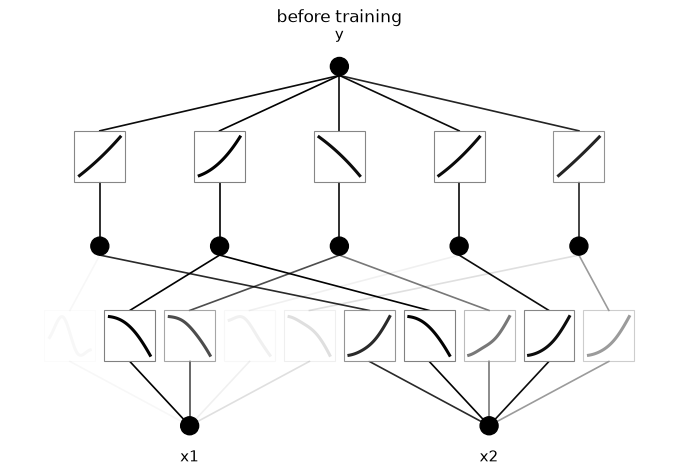

In [3]:
model(x_train)
fig, ax = model.plot(title="before training", in_vars=["x1", "x2"], out_vars=["y"])
plt.show()

train loss: 2.910e-04


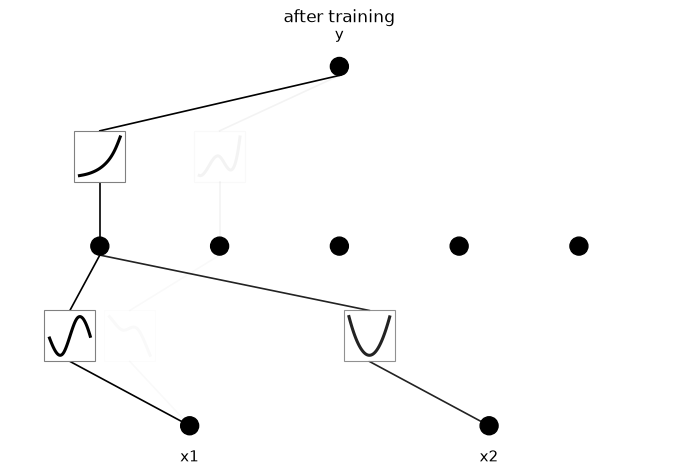

In [4]:
def fit(model, steps, lamb, lr=1.0):
    optimizer = torch.optim.LBFGS(model.parameters(), lr=lr, history_size=10, line_search_fn="strong_wolfe")
    for _ in range(steps):
        def closure():
            optimizer.zero_grad()
            loss = torch.nn.functional.mse_loss(model(x_train), y_train)
            loss = loss + lamb * model.activation_regularization_loss(x_train)
            loss.backward()
            return loss

        optimizer.step(closure)
    with torch.no_grad():
        return torch.nn.functional.mse_loss(model(x_train), y_train).item()


train_loss = fit(model, steps=60, lamb=0.002)
print(f"train loss: {train_loss:.3e}")

model(x_train)
fig, ax = model.plot(title="after training", in_vars=["x1", "x2"], out_vars=["y"])
plt.show()

Already visible above: most of the 5 hidden nodes have faded almost to invisibility — their edges barely vary, so they contribute almost nothing to the output. One node dominates.

## Prune the network

`node_th` is a threshold on each node's *relative* importance (std of its edge outputs, normalized to the layer's max) — a node survives only if both its strongest incoming edge and its strongest outgoing edge clear the threshold.

layer 1: keeping 1/5 nodes (dropped [1, 2, 3, 4])
width before: [2, 5, 1]  -> after: [2, 1, 1]


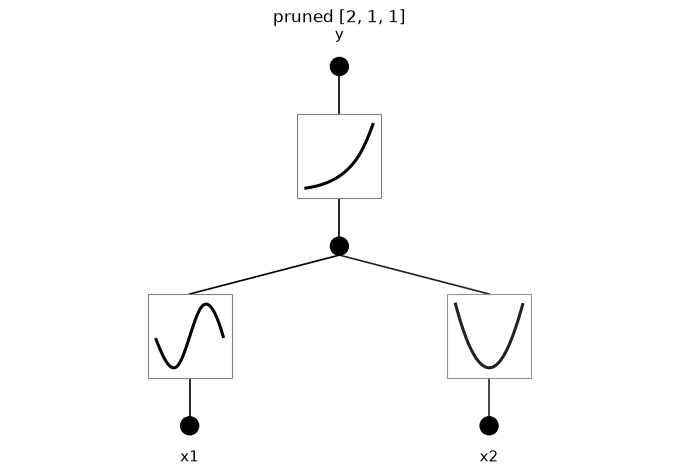

In [5]:
pruned = model.prune(x_train, node_th=0.3)
print("width before:", model.width, " -> after:", pruned.width)

pruned(x_train)
fig, ax = pruned.plot(title=f"pruned {pruned.width}", in_vars=["x1", "x2"], out_vars=["y"])
plt.show()

$f$ decomposes exactly as $\phi_3(\phi_1(x) + \phi_2(y))$ with $\phi_1 = \sin(\pi \cdot)$, $\phi_2 = (\cdot)^2$, $\phi_3 = \exp(\cdot)$ — a single hidden node is architecturally sufficient, and pruning found exactly that: `[2, 5, 1] -> [2, 1, 1]`. The two remaining input edges already look unmistakably like a parabola and a sine wave.

## Continue training the pruned network

In [6]:
train_loss = fit(pruned, steps=100, lamb=0.002)
pruned(x_train)
with torch.no_grad():
    test_loss = torch.nn.functional.mse_loss(pruned(x_test), y_test).item()
print(f"train loss: {train_loss:.3e}, test loss: {test_loss:.3e}")

train loss: 3.402e-04, test loss: 2.767e-04


## Attempt symbolic regression

`auto_symbolic()` tries every function in the library against every edge and locks in the best fit that clears `r2_threshold`, printing what it found (mirroring pykan's `fixing (l,i,j) with name, r2=...` output).

In [7]:
pruned.auto_symbolic(r2_threshold=0.9)

/Users/noah/Developer/personal/efficient-kan-ge/src/efficient_kan/symbolic.py:57: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(model, x_np, y_np, p0=p0, maxfev=10000)


fixing (0,0,0) with sin, r2=0.999877483459071


fixing (0,1,0) with x^2, r2=0.999972356747789


fixing (1,0,0) with exp, r2=0.9999571704104873


In [8]:
formula, var = pruned.symbolic_formula(var=["x1", "x2"])
print("Recovered symbolic formula:", formula[0])

Recovered symbolic formula: 0.9822*exp(1.694*(0.7691*x2 - 0.0001056)**2 + 1.015*sin(3.141*x1 - 0.001613)) + 0.01814


Edges that got fixed to a symbolic function are drawn in **red** instead of black — the same symbolic-vs-numeric color coding pykan uses.

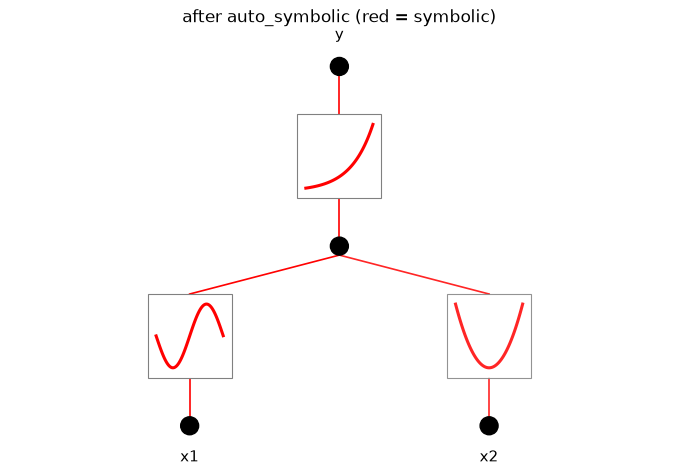

In [9]:
pruned(x_train)
fig, ax = pruned.plot(title="after auto_symbolic (red = symbolic)", in_vars=["x1", "x2"], out_vars=["y"])
plt.show()

Compare against the ground truth: $f(x, y) = \exp(\sin(\pi x) + y^2)$ — the fitted constants should land close to $\pi \approx 3.1416$ and the quadratic/exponential shape should be unmistakable.

**Caveat:** with only 1000 samples over a bounded domain, more than one library function can occasionally fit an edge's curve almost perfectly (e.g. `tanh` can mimic `exp` very closely over a narrow range) — if `auto_symbolic` doesn't pick the "obviously right" function on a given run, check the printed R² of the alternatives (`layer._fit_edge_symbolic(i, j, name)`) before assuming something is broken. This is a known limitation of affine-wrapped symbolic regression, not specific to this implementation.